# Stochastic Computing Arithmetic — From First Principles

**SC-NeuroCore v3.14** — Why a single AND gate computes multiplication.

Stochastic computing (Gaines 1969) represents real numbers as random
bitstreams where $\Pr(\text{bit}=1) = p$. Arithmetic operations map
to trivial logic gates:

| Operation | Unipolar $[0,1]$ | Bipolar $[-1,1]$ | Gate cost |
|-----------|-----------------|-----------------|----------|
| Multiply | AND | XNOR | 1 LUT |
| Scaled add | MUX | MUX | 1 LUT |
| Divide | CORDIV | CORDIV | ~4 LUTs |
| Square root | — | CORDIV(x,x) | ~4 LUTs |

This notebook derives each operation, proves error bounds, and
demonstrates convergence empirically.

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.utils.rng import RNG
from sc_neurocore import (
    BitstreamEncoder,
    bitstream_to_probability,
    generate_bernoulli_bitstream,
    generate_sobol_bitstream,
)
from sc_neurocore.core.bipolar import (
    bipolar_encode,
    bipolar_decode,
    bipolar_multiply,
)
from sc_neurocore.utils.bitstreams import sc_divide, adaptive_length

print("SC-NeuroCore arithmetic theory demo")

SC-NeuroCore arithmetic theory demo


## 1. Unipolar Multiplication: AND Gate

If $X$ and $Y$ are independent Bernoulli bitstreams with
$\Pr(X=1)=p_x$ and $\Pr(Y=1)=p_y$, then:

$$\Pr(X \wedge Y = 1) = \Pr(X=1) \cdot \Pr(Y=1) = p_x \cdot p_y$$

A single AND gate computes multiplication. The key requirement
is **decorrelation** — the two bitstreams must use independent
random number generators.

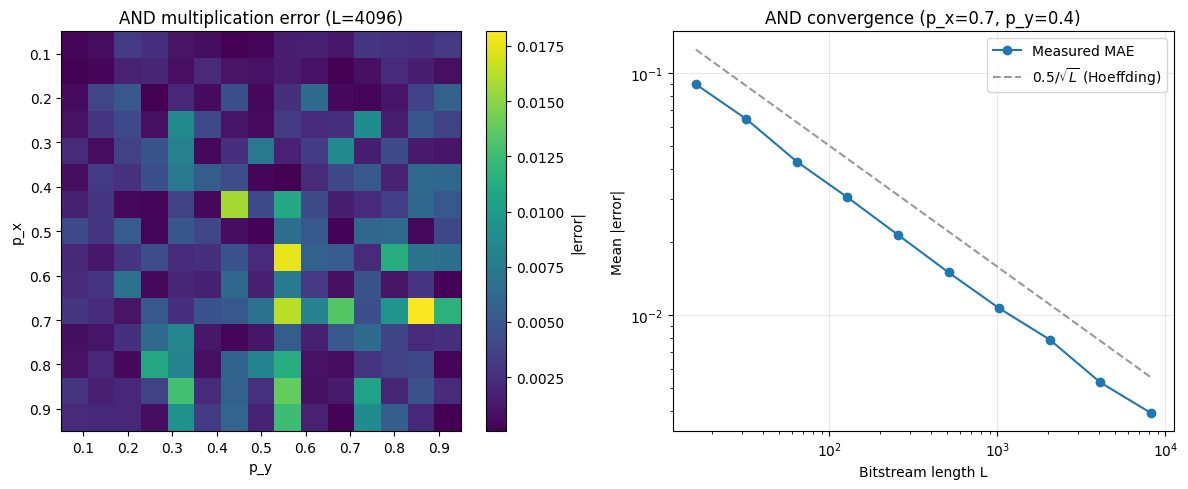

In [2]:
L = 4096

# Grid of (px, py) values
ps = np.linspace(0.05, 0.95, 15)
error_grid = np.zeros((len(ps), len(ps)))

for i, px in enumerate(ps):
    for j, py in enumerate(ps):
        x = generate_bernoulli_bitstream(px, L, rng=RNG(i * 100))
        y = generate_bernoulli_bitstream(py, L, rng=RNG(j * 100 + 50))
        z = x & y  # AND gate
        result = np.mean(z)
        expected = px * py
        error_grid[i, j] = abs(result - expected)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im = axes[0].imshow(error_grid, extent=[0.05, 0.95, 0.95, 0.05],
                     cmap="viridis", aspect="equal")
axes[0].set_xlabel("p_y")
axes[0].set_ylabel("p_x")
axes[0].set_title(f"AND multiplication error (L={L})")
plt.colorbar(im, ax=axes[0], label="|error|")

# Convergence vs L
lengths = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
px, py = 0.7, 0.4
n_trials = 200
mean_errors = []

for ll in lengths:
    errs = []
    for trial in range(n_trials):
        x = generate_bernoulli_bitstream(px, ll, rng=RNG(trial))
        y = generate_bernoulli_bitstream(py, ll, rng=RNG(trial + 10000))
        errs.append(abs(np.mean(x & y) - px * py))
    mean_errors.append(np.mean(errs))

axes[1].loglog(lengths, mean_errors, "o-", label="Measured MAE")
axes[1].loglog(lengths, [0.5 / np.sqrt(ll) for ll in lengths], "k--",
               alpha=0.4, label=r"$0.5/\sqrt{L}$ (Hoeffding)")
axes[1].set_xlabel("Bitstream length L")
axes[1].set_ylabel("Mean |error|")
axes[1].set_title(f"AND convergence (p_x={px}, p_y={py})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Bipolar Multiplication: XNOR Gate

For signed values $x, y \in [-1, 1]$, encode as
$p = (x+1)/2$ and use XNOR instead of AND:

$$\Pr(X \oplus Y = 1) = p_x p_y + (1-p_x)(1-p_y)$$

Decoding: $z = 2 \cdot \Pr(\text{XNOR}=1) - 1 = x \cdot y$.

This extends SC to signed weights — essential for neural networks.

In [3]:
L_bp = 2048

test_pairs = [
    (0.8, 0.5), (0.3, -0.7), (-0.6, 0.4),
    (-0.9, -0.3), (0.0, 0.5), (1.0, -1.0),
]

print(f"{'x':>6s}  {'y':>6s}  {'x*y':>8s}  {'XNOR':>8s}  {'error':>8s}")
print("-" * 42)

for x_val, y_val in test_pairs:
    x_bits = bipolar_encode(x_val, L_bp, rng=RNG(42))
    y_bits = bipolar_encode(y_val, L_bp, rng=RNG(99))
    z_bits = bipolar_multiply(x_bits, y_bits)
    result = bipolar_decode(z_bits)
    expected = x_val * y_val
    print(f"{x_val:6.2f}  {y_val:6.2f}  {expected:8.4f}  {result:8.4f}  "
          f"{abs(result - expected):8.4f}")

     x       y       x*y      XNOR     error
------------------------------------------
  0.80    0.50    0.4000    0.3760    0.0240
  0.30   -0.70   -0.2100   -0.2119    0.0019
 -0.60    0.40   -0.2400   -0.1953    0.0447
 -0.90   -0.30    0.2700    0.2910    0.0210
  0.00    0.50    0.0000   -0.0010    0.0010
  1.00   -1.00   -1.0000   -1.0000    0.0000


## 3. Scaled Addition: MUX Gate

A 2:1 multiplexer computes the scaled sum:

$$\Pr(Z=1) = s \cdot \Pr(X=1) + (1-s) \cdot \Pr(Y=1)$$

where $s = \Pr(\text{select}=1)$. For $s=0.5$ (fair coin),
this computes the average $(p_x + p_y)/2$.

For N-input addition, cascade MUX stages or use a $\log_2 N$
tree. The result is always normalised to $[0,1]$.

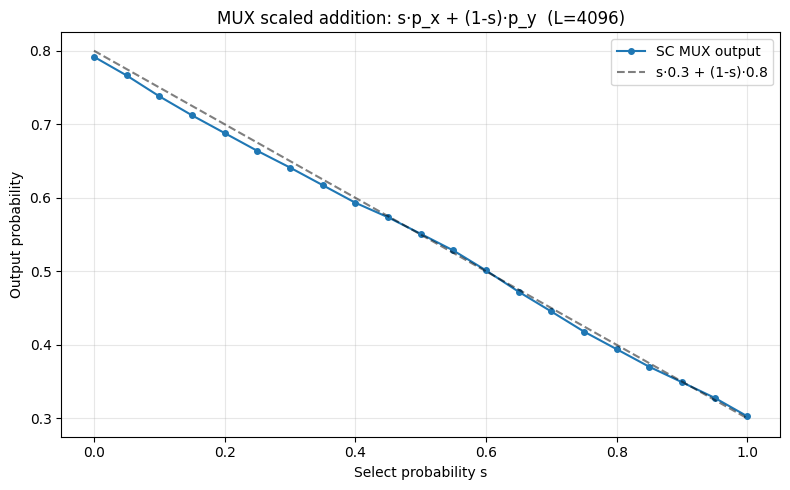

In [4]:
L_mux = 4096
rng = np.random.default_rng(42)

px, py = 0.3, 0.8
x = generate_bernoulli_bitstream(px, L_mux, rng=RNG(1))
y = generate_bernoulli_bitstream(py, L_mux, rng=RNG(2))

# Sweep select probability
s_values = np.linspace(0, 1, 21)
results = []
expected = []

for s in s_values:
    sel = generate_bernoulli_bitstream(s, L_mux, rng=RNG(3))
    z = np.where(sel, x, y)  # MUX: sel=1 → x, sel=0 → y
    results.append(np.mean(z))
    expected.append(s * px + (1 - s) * py)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(s_values, results, "o-", markersize=4, label="SC MUX output")
ax.plot(s_values, expected, "k--", alpha=0.5, label=f"s·{px} + (1-s)·{py}")
ax.set_xlabel("Select probability s")
ax.set_ylabel("Output probability")
ax.set_title(f"MUX scaled addition: s·p_x + (1-s)·p_y  (L={L_mux})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Division: CORDIV Circuit

Li et al. (2014) CORDIV state machine:

```
if x[t] == 1:          z[t] = 1
elif y[t] == 1:        z[t] = 0
else:                  z[t] = z[t-1]  (hold)
```

Converges to $\Pr(Z=1) \approx \Pr(X=1) / \Pr(Y=1)$ when
$p_x \leq p_y$ (numerator ≤ denominator). Cost: 2 gates + 1 flip-flop.

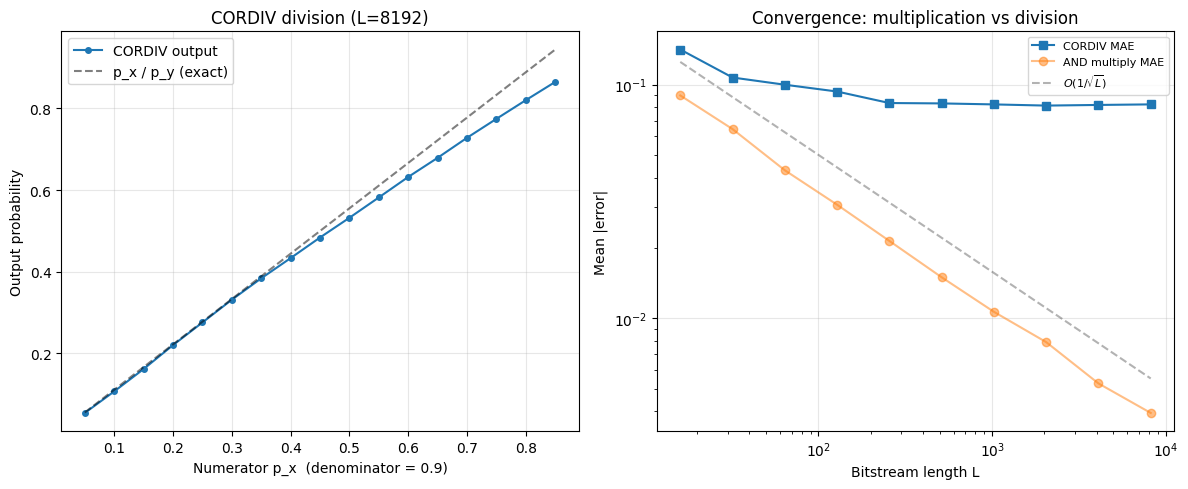

In [5]:
L_div = 8192

numerators = np.linspace(0.05, 0.85, 17)
denominator = 0.9

div_results = []
div_expected = []

for pn in numerators:
    x = generate_bernoulli_bitstream(pn, L_div, rng=RNG(42))
    y = generate_bernoulli_bitstream(denominator, L_div, rng=RNG(99))
    z = sc_divide(x, y)
    div_results.append(np.mean(z))
    div_expected.append(pn / denominator)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(numerators, div_results, "o-", markersize=4, label="CORDIV output")
axes[0].plot(numerators, div_expected, "k--", alpha=0.5, label="p_x / p_y (exact)")
axes[0].set_xlabel(f"Numerator p_x  (denominator = {denominator})")
axes[0].set_ylabel("Output probability")
axes[0].set_title(f"CORDIV division (L={L_div})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Error vs L for division
pn_test, pd_test = 0.3, 0.6
div_errors = []
for ll in lengths:
    errs = []
    for trial in range(100):
        xb = generate_bernoulli_bitstream(pn_test, ll, rng=RNG(trial))
        yb = generate_bernoulli_bitstream(pd_test, ll, rng=RNG(trial + 5000))
        zb = sc_divide(xb, yb)
        errs.append(abs(np.mean(zb) - pn_test / pd_test))
    div_errors.append(np.mean(errs))

axes[1].loglog(lengths, div_errors, "s-", label="CORDIV MAE")
axes[1].loglog(lengths, mean_errors, "o-", alpha=0.5, label="AND multiply MAE")
axes[1].loglog(lengths, [0.5 / np.sqrt(ll) for ll in lengths], "k--",
               alpha=0.3, label=r"$O(1/\sqrt{L})$")
axes[1].set_xlabel("Bitstream length L")
axes[1].set_ylabel("Mean |error|")
axes[1].set_title("Convergence: multiplication vs division")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Sobol vs Bernoulli: Low-Discrepancy Advantage

Bernoulli bitstreams converge at $O(1/\sqrt{L})$ (CLT).
Sobol quasi-random sequences converge at $O(1/L)$ —
quadratically faster — because they fill the probability
space more uniformly.

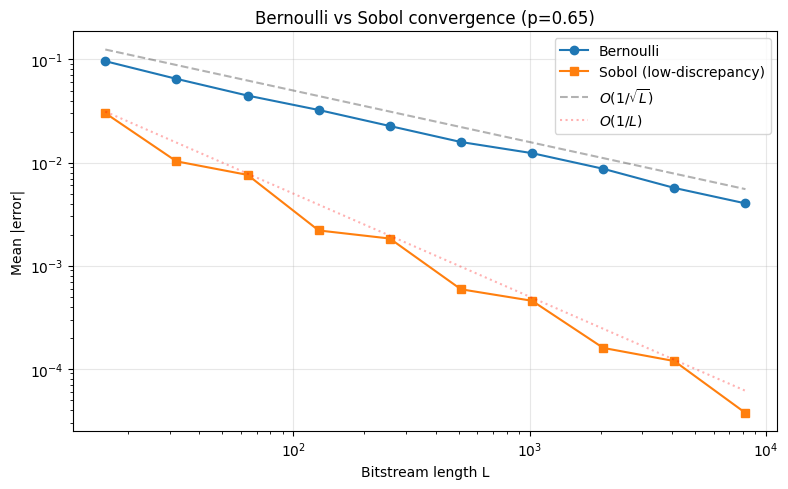

In [6]:
target_p = 0.65
n_trials = 200

bern_errors = []
sobol_errors = []

for ll in lengths:
    b_errs, s_errs = [], []
    for trial in range(n_trials):
        b = generate_bernoulli_bitstream(target_p, ll, rng=RNG(trial))
        b_errs.append(abs(np.mean(b) - target_p))
        s = generate_sobol_bitstream(target_p, ll, seed=trial)
        s_errs.append(abs(np.mean(s) - target_p))
    bern_errors.append(np.mean(b_errs))
    sobol_errors.append(np.mean(s_errs))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(lengths, bern_errors, "o-", label="Bernoulli")
ax.loglog(lengths, sobol_errors, "s-", label="Sobol (low-discrepancy)")
ax.loglog(lengths, [0.5 / np.sqrt(ll) for ll in lengths], "k--",
          alpha=0.3, label=r"$O(1/\sqrt{L})$")
ax.loglog(lengths, [0.5 / ll for ll in lengths], "r:",
          alpha=0.3, label=r"$O(1/L)$")
ax.set_xlabel("Bitstream length L")
ax.set_ylabel("Mean |error|")
ax.set_title(f"Bernoulli vs Sobol convergence (p={target_p})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Adaptive Bitstream Length (Hoeffding Bound)

Given target error $\epsilon$ and confidence $1-\delta$, the
minimum bitstream length is:

$$L \geq \frac{\ln(2/\delta)}{2\epsilon^2}$$

(Hoeffding 1963). `adaptive_length()` computes this bound,
enabling per-layer precision tuning.

  Target ε   L (95%)   L (99%)   L (99.9%)
------------------------------------------
     0.100       256       512         512
     0.050      1024      2048        2048
     0.020      8192      8192       16384
     0.010     32768     32768       65536
     0.005     65536     65536       65536
     0.002     65536     65536       65536
     0.001     65536     65536       65536


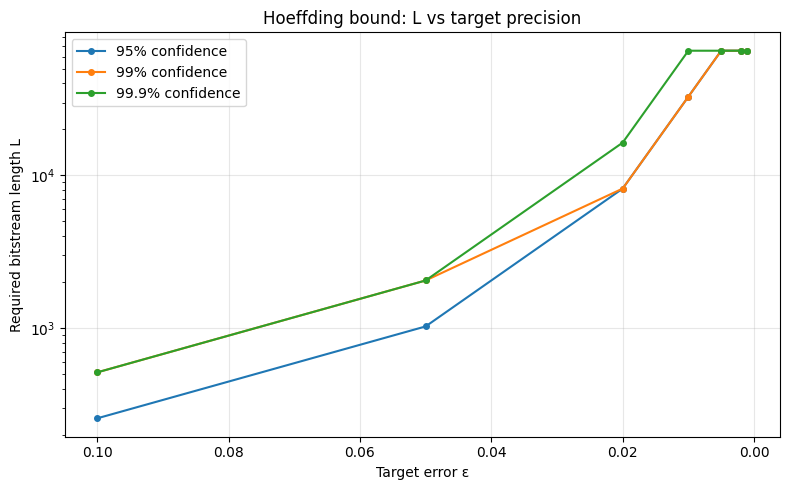

In [7]:
epsilons = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001]

print(f"{'Target ε':>10s}  {'L (95%)':>8s}  {'L (99%)':>8s}  {'L (99.9%)':>10s}")
print("-" * 42)
for eps in epsilons:
    l95 = adaptive_length(0.5, eps, confidence=0.95)
    l99 = adaptive_length(0.5, eps, confidence=0.99)
    l999 = adaptive_length(0.5, eps, confidence=0.999)
    print(f"{eps:10.3f}  {l95:8d}  {l99:8d}  {l999:10d}")

fig, ax = plt.subplots(figsize=(8, 5))
for conf, label in [(0.95, "95%"), (0.99, "99%"), (0.999, "99.9%")]:
    lens = [adaptive_length(0.5, e, confidence=conf) for e in epsilons]
    ax.semilogy(epsilons, lens, "o-", markersize=4, label=f"{label} confidence")
ax.set_xlabel("Target error ε")
ax.set_ylabel("Required bitstream length L")
ax.set_title("Hoeffding bound: L vs target precision")
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

## Summary: SC Arithmetic at a Glance

| Operation | Gate | Domain | Error | FPGA cost |
|-----------|------|--------|-------|-----------|
| Multiply | AND | Unipolar $[0,1]$ | $O(1/\sqrt{L})$ | 1 LUT |
| Multiply | XNOR | Bipolar $[-1,1]$ | $O(1/\sqrt{L})$ | 1 LUT |
| Scaled add | MUX | Both | $O(1/\sqrt{L})$ | 1 LUT |
| Divide | CORDIV | Unipolar | $O(1/\sqrt{L})$ | ~4 LUTs |
| Encode | LFSR + CMP | — | — | ~20 LUTs |
| Accumulate | Popcount tree | — | exact | $\log_2 N$ LUTs |

**Key trade-off:** Precision scales as $O(1/\sqrt{L})$ with
circuit area scaling as $O(L)$. For 1% error: L ≈ 2500
(Bernoulli) or L ≈ 100 (Sobol). The Sobol advantage justifies
the extra ~10 LUTs for the quasi-random generator.

**Decorrelation is critical.** Correlated inputs produce biased
results. SC-NeuroCore uses per-synapse independent LFSRs
or Sobol dimensions to maintain decorrelation across the network.